In [ ]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

In [ ]:
DATA_DIR = '/content/drive/MyDrive/kaggle/SteamBamboo'

train  = pd.read_csv(f'{DATA_DIR}/train.csv')
test   = pd.read_csv(f'{DATA_DIR}/test.csv')
sample = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

print('train :', train.shape)
print('test  :', test.shape)
print('sample:', sample.shape)
train.head(3)

train : (100684, 15)
test  : (25171, 14)
sample: (25171, 2)


,ID,Release date,Required age,Price,Discount,About the game,Supported languages,Header image,Achievements,Categories,Genres,Windows,Mac,Linux,popularity_score
0,2867825,"Sep 22, 2021",0,7.99,0,9.23 The playing card editing function has bee...,"['Simplified Chinese', 'English']",https://shared.akamai.steamstatic.com/store_it...,0,"Single-player,Family Sharing","Casual,Indie,RPG,Simulation,Strategy",True,False,False,0.259434
1,1419610,"Oct 2, 2017",0,4.99,50,"From Cosmo D , the creator of the freeware hit...",['English'],https://shared.akamai.steamstatic.com/store_it...,17,"Single-player,Steam Achievements,Steam Trading...","Adventure,Casual,Indie",True,True,False,0.462399
2,5614226,"Nov 30, 2022",0,0.59,0,Gravity Maze is a 2D physics maze game in whic...,['English'],https://shared.akamai.steamstatic.com/store_it...,7,"Single-player,Steam Achievements,Steam Worksho...","Casual,Indie,Simulation,Strategy,Early Access",True,False,True,0.195695


count    100684.000000
mean          0.259049
std           0.152751
min           0.000000
25%           0.195695
50%           0.304363
75%           0.340688
max           0.944764
Name: popularity_score, dtype: float64


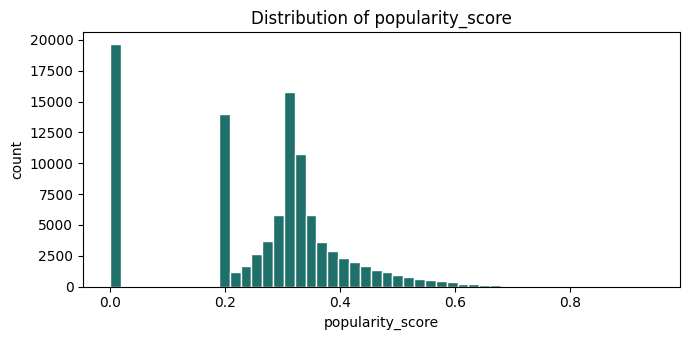

In [ ]:
y = train['popularity_score']
print(y.describe())

plt.figure(figsize=(7, 3.5))
plt.hist(y, bins=50, color='#1f6f6a', edgecolor='white')
plt.title('Distribution of popularity_score')
plt.xlabel('popularity_score'); plt.ylabel('count')
plt.tight_layout(); plt.show()

In [ ]:
print('Number of missing values:')
print(train.isna().sum())
print()
print('dtypes:')
print(train.dtypes)

Number of missing values:
ID                        0
Release date              0
Required age              0
Price                     0
Discount                  0
About the game         6773
Supported languages       0
Header image             66
Achievements              0
Categories             7185
Genres                 6735
Windows                   0
Mac                       0
Linux                     0
popularity_score          0
dtype: int64

dtypes:
ID                       int64
Release date            object
Required age             int64
Price                  float64
Discount                 int64
About the game          object
Supported languages     object
Header image            object
Achievements             int64
Categories              object
Genres                  object
Windows                   bool
Mac                       bool
Linux                     bool
popularity_score       float64
dtype: object


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("[1. Required Age & Popularity Score Analysis]")
print("-" * 50)
age_summary = train.groupby('Required age')['popularity_score'].agg(['count', 'mean', 'std']).reset_index()
print(age_summary.to_string(index=False))

print("\n[2. Platform Combinations (Windows, Mac, Linux) & Popularity Analysis]")
print("-" * 50)
# Create platform support combinations (e.g., Windows_True / Mac_False / Linux_False)
train['platform_combo'] = (
    "Win:" + train['Windows'].astype(str) +
    " | Mac:" + train['Mac'].astype(str) +
    " | Lin:" + train['Linux'].astype(str)
)
platform_summary = train.groupby('platform_combo')['popularity_score'].agg(['count', 'mean']).sort_values(by='count', ascending=False)
print(platform_summary)

print("\n[3. Price Range Popularity & Missing Values Validation]")
print("-" * 50)
raw_price = pd.to_numeric(train['Price'], errors='coerce')
print(f"Number of NaN (missing values) in Price column: {raw_price.isna().sum()}")

# Binning prices into ranges (Free, Low, Mid, High, etc.)
price_bins = [-1, 0, 5, 15, 30, 70, 1000]
price_labels = ['Free(0)', 'Ultra-Low(~5)', 'Budget(~15)', 'Mid-Tier(~30)', 'Premium(~70)', 'AAA+(70+)']
train['price_group'] = pd.cut(raw_price.fillna(-1), bins=price_bins, labels=price_labels)
price_summary = train.groupby('price_group', observed=False)['popularity_score'].agg(['count', 'mean'])
print(price_summary)

print("\n[4. Discount Existence & Scale Analysis]")
print("-" * 50)
discount_raw = pd.to_numeric(train['Discount'], errors='coerce').fillna(0)
print(f"Percentage of games currently offering a discount: {(discount_raw > 0).mean()*100:.2f}%")
print(f"Maximum discount rate: {discount_raw.max()}%")
train['discount_group'] = pd.cut(discount_raw, bins=[-1, 0, 30, 50, 75, 100], labels=['No Discount', 'Low(~30%)', 'Mid(~50%)', 'High(~75%)', 'Ultra(75%+)'])
print(train.groupby('discount_group', observed=False)['popularity_score'].agg(['count', 'mean']))

print("\n[5. Genres / Categories Top Items Score Gap Exploration]")
print("-" * 50)
def get_top_tags_mean(df, col_name):
    # Split by comma, count, and calculate mean
    expanded = df[[col_name, 'popularity_score']].copy()
    expanded[col_name] = expanded[col_name].astype(str).str.split(',')
    expanded = expanded.explode(col_name)
    expanded[col_name] = expanded[col_name].str.strip().str.lower()

    # Exclude minor tags (must appear at least 500 times)
    summary = expanded.groupby(col_name)['popularity_score'].agg(['count', 'mean'])
    return summary[summary['count'] >= 500].sort_values(by='mean', ascending=False)

print("\n[Genres Top 15 Popularity Ranking]")
print(get_top_tags_mean(train, 'Genres').head(15))

print("\n[Categories Top 15 Popularity Ranking]")
print(get_top_tags_mean(train, 'Categories').head(15))

[1. Required Age & Popularity Score Analysis]
--------------------------------------------------
 Required age  count     mean      std
            0  99647 0.257010 0.151138
            1      1 0.325683      NaN
            3      5 0.273936 0.048506
            6      2 0.395489 0.034844
            7      4 0.260981 0.052629
           10     24 0.309804 0.207825
           12     18 0.341971 0.117760
           13    138 0.424212 0.174213
           14      1 0.290408      NaN
           15      3 0.331047 0.081233
           16     27 0.480943 0.154366
           17    677 0.495543 0.162869
           18    135 0.340908 0.183631
           20      1 0.195695      NaN
           21      1 0.195695      NaN

[2. Platform Combinations (Windows, Mac, Linux) & Popularity Analysis]
--------------------------------------------------
                                  count      mean
platform_combo                                   
Win:True | Mac:False | Lin:False  79801  0.247201
Win:Tr

Transforming dataframe for correlation analysis...

[Correlation Rankings with Popularity Score]
Days_Since_Release   : +0.5106
Discount             : +0.3824
Price_Log            : +0.3229
Num_Languages_Log    : +0.1364
Required_Age         : +0.1319
Price_Raw            : +0.0784
Achievements         : +0.0711
Ach_Density_Log      : +0.0334
Final_Price          : +0.0332
Ach_Density          : +0.0266
Num_Languages        : -0.0562
URL_Length           : -0.3740


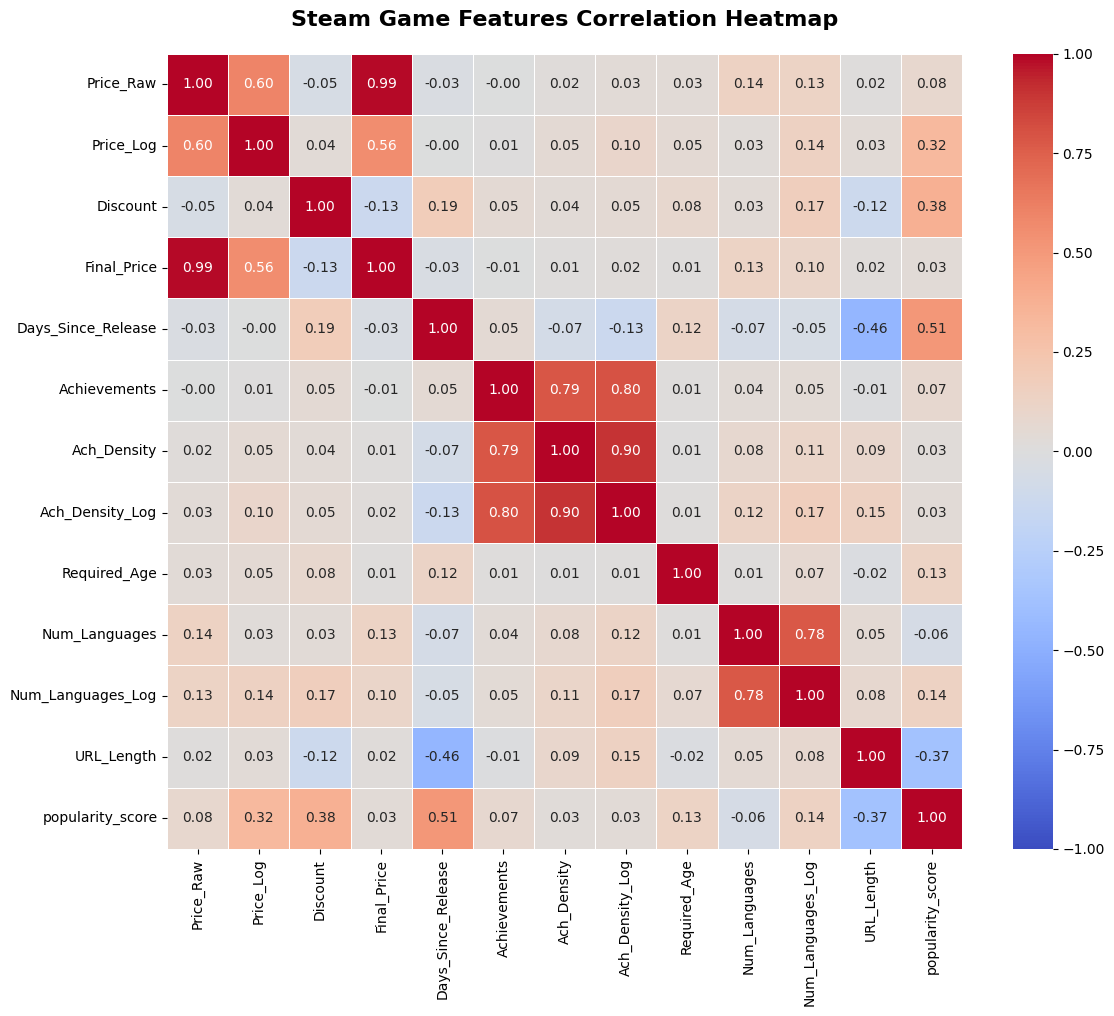

In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. Define Dependency Helper Functions
# ==========================================
def count_languages_eda(s):
    if pd.isna(s) or not s or str(s).strip() in ['', '[]']:
        return 1
    s_str = str(s).strip()
    if s_str.startswith('[') and s_str.endswith(']'):
        try:
            parsed_list = ast.literal_eval(s_str)
            if isinstance(parsed_list, list):
                return len(parsed_list)
        except Exception:
            pass
    items = [x for x in s_str.replace('[', '').replace(']', '').replace("'", "").split(',') if x.strip()]
    return len(items) if items else 1

# ==========================================
# 1. Numerical Data Transformation and Mapping Functions
# ==========================================
def get_eda_df(df):
    eda_df = pd.DataFrame(index=df.index)

    # 1) Price and Discount Structure
    raw_price = pd.to_numeric(df['Price'], errors='coerce').fillna(0)
    discount = pd.to_numeric(df['Discount'], errors='coerce').fillna(0)
    eda_df['Price_Raw'] = raw_price
    eda_df['Price_Log'] = np.log1p(raw_price)
    eda_df['Discount'] = discount
    eda_df['Final_Price'] = raw_price * (1 - discount / 100)

    # 2) Time and Release Date-based Elapsed Days
    d = pd.to_datetime(df['Release date'], errors='coerce', format='mixed')
    if not d.isna().all():
        median_date = d.dropna().iloc[len(d.dropna()) // 2]
        d = d.fillna(median_date)
    else:
        d = d.fillna(pd.Timestamp('2027-01-01'))
    days = (pd.Timestamp('2027-01-01') - d).dt.days.clip(lower=0)
    eda_df['Days_Since_Release'] = days

    # 3) Achievements and Density
    achievements = pd.to_numeric(df['Achievements'], errors='coerce').fillna(0)
    eda_df['Achievements'] = achievements
    eda_df['Ach_Density'] = achievements / days.clip(lower=1)
    eda_df['Ach_Density_Log'] = np.log1p(eda_df['Ach_Density'])

    # 4) Required Age and Number of Languages (Error correction completed)
    eda_df['Required_Age'] = pd.to_numeric(df['Required age'], errors='coerce').fillna(0)
    eda_df['Num_Languages'] = df['Supported languages'].apply(count_languages_eda)
    eda_df['Num_Languages_Log'] = np.log1p(eda_df['Num_Languages'])

    # 5) Image URL Length
    img_url = df['Header image'].astype(str).fillna('')
    eda_df['URL_Length'] = img_url.str.len()

    # Safe mapping of target variable
    if 'popularity_score' in df.columns:
        eda_df['popularity_score'] = df['popularity_score']

    return eda_df

# 2. Prepare and Transform Dataset for EDA
print("Transforming dataframe for correlation analysis...")
df_corr_analysis = get_eda_df(train)

# 3. Print Correlation Rankings with Target Variable (popularity_score)
if 'popularity_score' in df_corr_analysis.columns:
    corr_with_target = df_corr_analysis.corr()['popularity_score'].sort_values(ascending=False)
    print("\n==========================================")
    print("[Correlation Rankings with Popularity Score]")
    print("==========================================")
    for col, val in corr_with_target.items():
        if col != 'popularity_score':
            print(f"{col:<20} : {val:+.4f}")
    print("==========================================")

# 4. Calculate Correlation Matrix for All Features and Visualize as Heatmap
corr_matrix = df_corr_analysis.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0, vmax=1.0,
    linewidths=0.5,
    square=True
)
plt.title("Steam Game Features Correlation Heatmap", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def analyze_image_url_eda(df):
    eda_df = pd.DataFrame(index=df.index)

    # Preprocess text for analysis
    img_url = df['Header image'].astype(str).fillna('').str.lower()

    # 1. Whether official Steam CDN is used
    eda_df['is_steam_cdn'] = img_url.str.contains('steamstatic|steamcdn|akamai', case=False).astype(int)

    # 2. Presence of cache-busting parameters (?t= or v=)
    eda_df['has_cache_buster'] = (img_url.str.contains('\?t=', case=False) | img_url.str.contains('v=', case=False)).astype(int)

    # 3. Whether the image format is PNG
    eda_df['is_png'] = img_url.str.contains('\.png', case=False).astype(int)

    # Map target variable
    if 'popularity_score' in df.columns:
        eda_df['popularity_score'] = df['popularity_score']

    return eda_df

# Run EDA analysis
print("Running temporary analysis for image URL hypothesis testing...")
df_img_eda = analyze_image_url_eda(train)

# Print results
print("\n" + "="*50)
print("[Hypothesis 1] Popularity Comparison by Official Steam CDN Usage")
print("="*50)
print(df_img_eda.groupby('is_steam_cdn')['popularity_score'].agg(['count', 'mean', 'std']))

print("\n" + "="*50)
print("[Hypothesis 2] Popularity Comparison by Presence of Cache-Busting Parameters")
print("="*50)
print(df_img_eda.groupby('has_cache_buster')['popularity_score'].agg(['count', 'mean', 'std']))

print("\n" + "="*50)
print("[Hypothesis 3] Popularity Comparison by PNG Format Usage")
print("="*50)
print(df_img_eda.groupby('is_png')['popularity_score'].agg(['count', 'mean', 'std']))

<>:14: SyntaxWarning: invalid escape sequence '\?'
<>:17: SyntaxWarning: invalid escape sequence '\.'
<>:14: SyntaxWarning: invalid escape sequence '\?'
<>:17: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_990/200488893.py:14: SyntaxWarning: invalid escape sequence '\?'
  eda_df['has_cache_buster'] = (img_url.str.contains('\?t=', case=False) | img_url.str.contains('v=', case=False)).astype(int)
/tmp/ipykernel_990/200488893.py:17: SyntaxWarning: invalid escape sequence '\.'
  eda_df['is_png'] = img_url.str.contains('\.png', case=False).astype(int)


Running temporary analysis for image URL hypothesis testing...

[Hypothesis 1] Popularity Comparison by Official Steam CDN Usage
               count      mean       std
is_steam_cdn                            
0                 66  0.191613  0.168102
1             100618  0.259094  0.152731

[Hypothesis 2] Popularity Comparison by Presence of Cache-Busting Parameters
                   count      mean       std
has_cache_buster                            
0                     66  0.191613  0.168102
1                 100618  0.259094  0.152731

[Hypothesis 3] Popularity Comparison by PNG Format Usage
         count      mean       std
is_png                            
0       100684  0.259049  0.152751


In [ ]:
import pandas as pd
import numpy as np
from pandas import Timestamp

REFERENCE_DATE = Timestamp('2027-01-01')
print(f"Reference date (REFERENCE_DATE) has been set to {REFERENCE_DATE}.")

def analyze_release_bins(df):
    # Calculate release date (identical to v12/v15 logic)
    d = pd.to_datetime(df['Release date'], errors='coerce', format='mixed')
    days = (REFERENCE_DATE - d).dt.days.fillna(0)

    # Create dataframe for analysis
    bin_df = pd.DataFrame({'popularity_score': df['popularity_score']})

    # Binning based on 30 days / 90 days / 365 days
    bin_df['is_new_within_30'] = (days <= 30).astype(int)
    bin_df['is_new_within_90'] = ((days > 30) & (days <= 90)).astype(int)
    bin_df['is_old_over_365'] = (days > 365).astype(int)

    # Summarize results
    results = {}
    for col in ['is_new_within_30', 'is_new_within_90', 'is_old_over_365']:
        results[col] = bin_df.groupby(col)['popularity_score'].mean()

    return results

# Run EDA
print("Analyzing popularity distribution by time intervals...")
bin_analysis = analyze_release_bins(train)

for category, stats in bin_analysis.items():
    print(f"\n[{category}]")
    print(stats)

Reference date (REFERENCE_DATE) has been set to 2027-01-01 00:00:00.
Analyzing popularity distribution by time intervals...

[is_new_within_30]
is_new_within_30
0    0.259049
Name: popularity_score, dtype: float64

[is_new_within_90]
is_new_within_90
0    0.259049
Name: popularity_score, dtype: float64

[is_old_over_365]
is_old_over_365
0    0.017675
1    0.265584
Name: popularity_score, dtype: float64


In [ ]:
# 1. First, create the column in the dataframe
d = pd.to_datetime(train['Release date'], errors='coerce', format='mixed')
days = (REFERENCE_DATE - d).dt.days.fillna(0)
train['is_old_over_365'] = (days > 365).astype(int)

# 2. Now running value_counts() will output the results properly
print("Distribution of new releases (< 1 year) vs older games (>= 1 year) in the dataset:")
print(train['is_old_over_365'].value_counts())

Distribution of new releases (< 1 year) vs older games (>= 1 year) in the dataset:
is_old_over_365
1    98030
0     2654
Name: count, dtype: int64


In [ ]:
# 1. Convert 'Release date' to datetime
release_dates = pd.to_datetime(train['Release date'], errors='coerce')

# 2. Check the oldest game
oldest_game_date = release_dates.min()
print(f"Release date of the oldest game: {oldest_game_date.strftime('%Y-%m-%d')}")

# 3. Calculate the number of games for each period
# Based on current date (July 15, 2026)
current_date = pd.Timestamp('2026-07-15')

days_diff = (current_date - release_dates).dt.days

count_3yr = (days_diff >= 3 * 365).sum()
count_5yr = (days_diff >= 5 * 365).sum()

print(f"Games older than 3 years: {count_3yr}")
print(f"Games older than 5 years: {count_5yr}")

Release date of the oldest game: 1997-06-30
Games older than 3 years: 56196
Games older than 5 years: 35957


In [ ]:
# 1. Extract year (handle NaNs and convert to numeric)
train['release_year'] = pd.to_datetime(train['Release date'], errors='coerce').dt.year

# 2. Calculate average popularity by release year
yearly_popularity = train.groupby('release_year')['popularity_score'].mean()

# 3. Organize into a dataframe and print
print("Trend of average popularity by release year:")
print(yearly_popularity.sort_index())

# 4. Check correlation
correlation = train[['release_year', 'popularity_score']].corr().iloc[0, 1]
print(f"\nCorrelation coefficient between release year and popularity: {correlation:.4f}")

Trend of average popularity by release year:
release_year
1997    0.544358
1998    0.723059
1999    0.610571
2000    0.631366
2001    0.560804
2002    0.593826
2003    0.621530
2004    0.683949
2005    0.483225
2006    0.476271
2007    0.506172
2008    0.454233
2009    0.430758
2010    0.439037
2011    0.473350
2012    0.481636
2013    0.460596
2014    0.423789
2015    0.399402
2016    0.380868
2017    0.352393
2018    0.334728
2019    0.328919
2020    0.327957
2021    0.282222
2022    0.261922
2023    0.250044
2024    0.239118
2025    0.151577
2026    0.017675
Name: popularity_score, dtype: float64

Correlation coefficient between release year and popularity: -0.5080


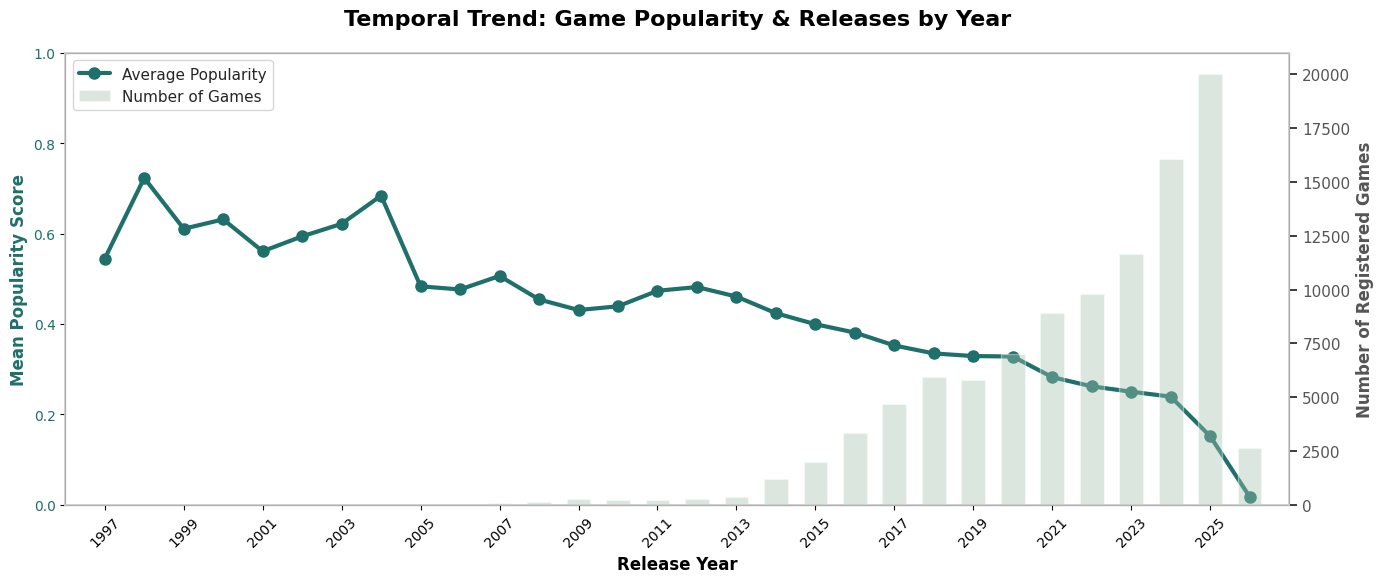

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation and Preprocessing
# Convert Release date to datetime and extract year
train['Release_Year'] = pd.to_datetime(train['Release date'], errors='coerce', format='mixed').dt.year

# Filter data for normal year range (1997~2026) only
yearly_data = train[(train['Release_Year'] >= 1997) & (train['Release_Year'] <= 2026)].copy()

# Aggregate mean popularity and game count by release year
year_summary = yearly_data.groupby('Release_Year').agg(
    mean_popularity=('popularity_score', 'mean'),
    game_count=('popularity_score', 'count')
).reset_index()

# 2. Visualization Setup
fig, ax1 = plt.subplots(figsize=(14, 6))

# Set graph theme
sns.set_theme(style="whitegrid")

# [Right y-axis] Number of games by release year -> Draw bar plot first.
ax2 = ax1.twinx()
color_bar = '#a3c1ad'
ax2.bar(
    year_summary['Release_Year'],
    year_summary['game_count'],
    color=color_bar,
    alpha=0.4,
    label='Number of Games',
    width=0.6
)
ax2.set_ylabel('Number of Registered Games', fontsize=12, color='#555555', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#555555')
ax2.grid(False)

# [Left y-axis] Mean popularity by release year -> Line plot
color_line = '#1f6f6a'
ax1.plot(
    year_summary['Release_Year'],
    year_summary['mean_popularity'],
    color=color_line,
    linewidth=3,
    marker='o',
    markersize=8,
    label='Average Popularity'
)
ax1.set_title('Temporal Trend: Game Popularity & Releases by Year', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Release Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Popularity Score', fontsize=12, color=color_line, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_line)
ax1.set_ylim(0, 1.0)

# Explicitly set x-axis range and tick intervals (safe mapping)
ax1.set_xlim(1996, 2027)
ax1.set_xticks(range(1997, 2027, 2))
ax1.set_xticklabels(range(1997, 2027, 2), rotation=45)

# Display integrated legend
lines, labels = ax1.get_legend_handles_labels()
bars, labels_bar = ax2.get_legend_handles_labels()
ax1.legend(lines + bars, labels + labels_bar, loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

/tmp/ipykernel_990/2050531617.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_990/2050531617.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


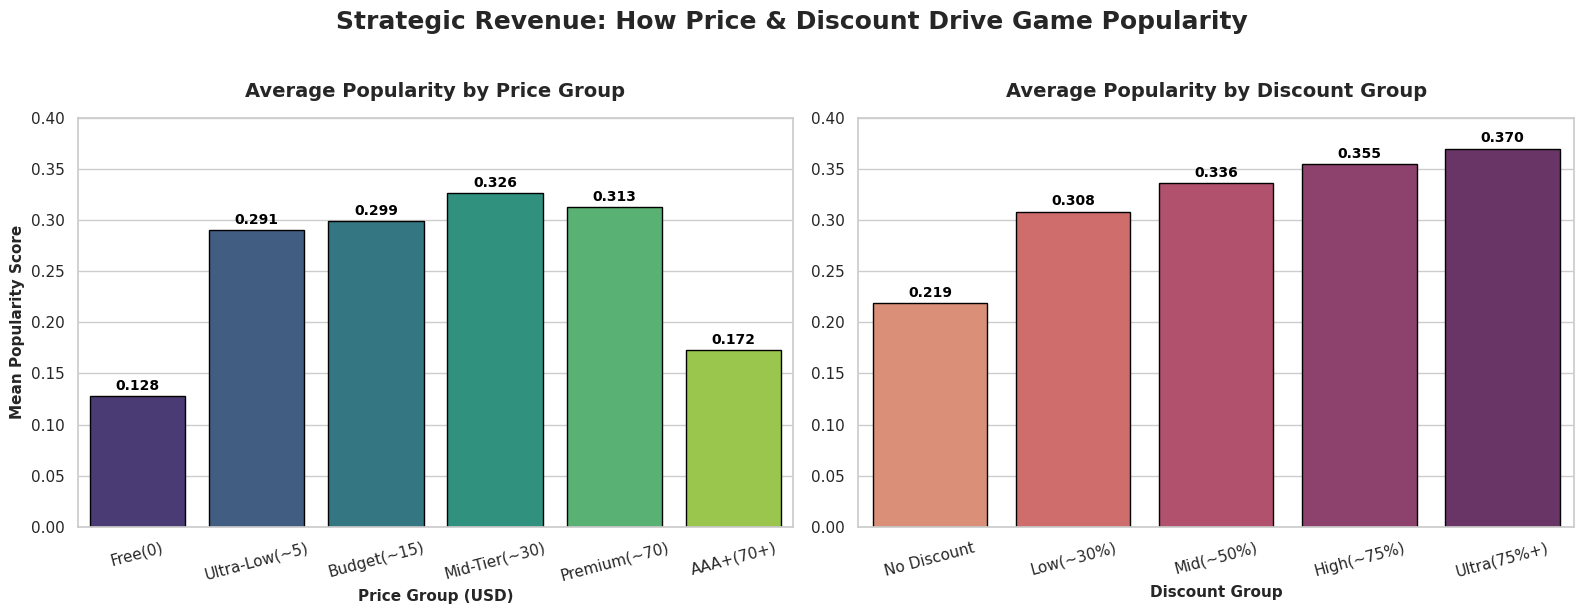

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data preprocessing and binning (Based on logic declared in Colab)
raw_price = pd.to_numeric(train['Price'], errors='coerce').fillna(0)
discount_raw = pd.to_numeric(train['Discount'], errors='coerce').fillna(0)

# Group price ranges into bins
price_bins = [-1, 0, 5, 15, 30, 70, 1000]
price_labels = ['Free(0)', 'Ultra-Low(~5)', 'Budget(~15)', 'Mid-Tier(~30)', 'Premium(~70)', 'AAA+(70+)']
train['price_group'] = pd.cut(raw_price, bins=price_bins, labels=price_labels)

# Group discount rate ranges into bins
discount_bins = [-1, 0, 30, 50, 75, 100]
discount_labels = ['No Discount', 'Low(~30%)', 'Mid(~50%)', 'High(~75%)', 'Ultra(75%+)']
train['discount_group'] = pd.cut(discount_raw, bins=discount_bins, labels=discount_labels)

# 2. Visualization (1 row, 2 columns subplots)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# [Left Graph] Average Popularity by Price Group
color_palette_price = sns.color_palette("viridis", len(price_labels))
sns.barplot(
    data=train,
    x='price_group',
    y='popularity_score',
    ax=axes[0],
    palette=color_palette_price,
    errorbar=None,
    edgecolor='black',
    linewidth=1
)
axes[0].set_title('Average Popularity by Price Group', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Price Group (USD)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Mean Popularity Score', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 0.4)
axes[0].tick_params(axis='x', rotation=15)

# Annotate values on top of each bar (improves readability)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.3f}",
                     (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                     ha='center', va='center', fontsize=10, fontweight='bold', color='black')


# [Right Graph] Average Popularity by Discount Group
color_palette_disc = sns.color_palette("flare", len(discount_labels))
sns.barplot(
    data=train,
    x='discount_group',
    y='popularity_score',
    ax=axes[1],
    palette=color_palette_disc,
    errorbar=None,
    edgecolor='black',
    linewidth=1
)
axes[1].set_title('Average Popularity by Discount Group', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Discount Group', fontsize=11, fontweight='bold')
axes[1].set_ylabel('', fontsize=11)
axes[1].set_ylim(0, 0.4)
axes[1].tick_params(axis='x', rotation=15)

# Annotate values on top of each bar
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.3f}",
                     (p.get_x() + p.get_width() / 2., p.get_height() + 0.01),
                     ha='center', va='center', fontsize=10, fontweight='bold', color='black')

plt.suptitle('Strategic Revenue: How Price & Discount Drive Game Popularity', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_990/4146638379.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


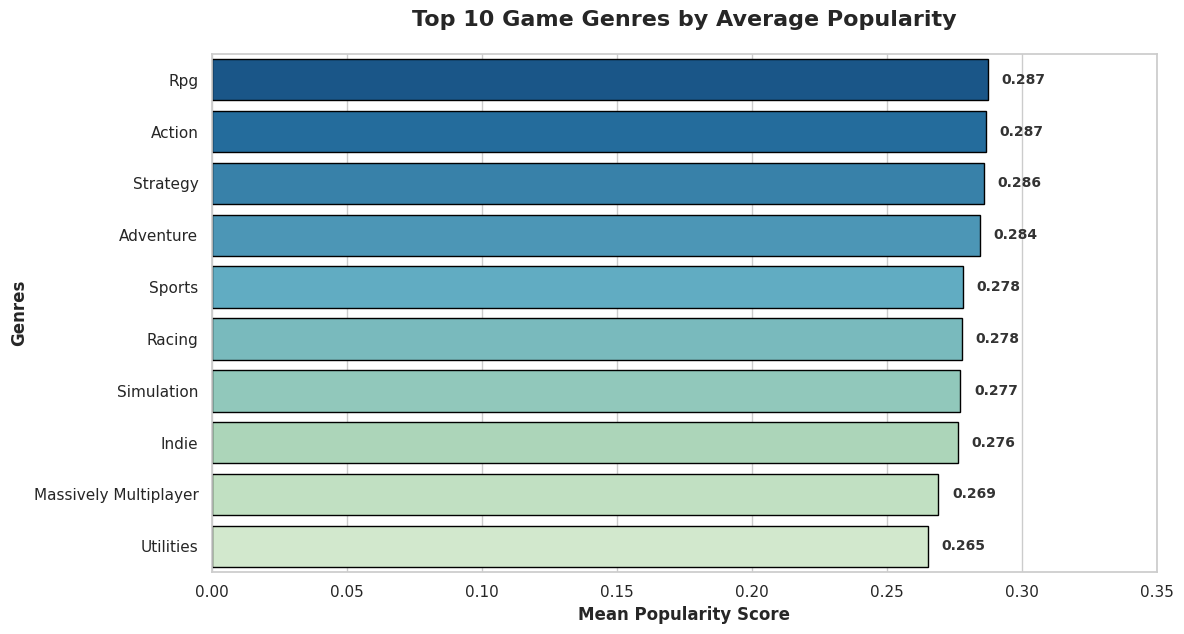

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Genres data preprocessing (exclude missing values and split individual genres)
# Temporarily replace rows with missing Genres to 'Unknown' and split
genres_df = train[['Genres', 'popularity_score']].copy()
genres_df['Genres'] = genres_df['Genres'].fillna('Unknown').astype(str)

# Split by comma (,) and expand into rows
genres_df['Genre_Split'] = genres_df['Genres'].str.split(',')
exploded_genres = genres_df.explode('Genre_Split')

# Remove whitespace, convert to lowercase, and then title case for visualization
exploded_genres['Genre_Clean'] = exploded_genres['Genre_Split'].str.strip().str.title()

# Exclude minor genres or handled missing values like 'Nan', 'Unknown', ''
filtered_genres = exploded_genres[~exploded_genres['Genre_Clean'].isin(['Nan', 'Unknown', ''])].copy()

# 2. Aggregate mean popularity and game count by genre
genre_summary = filtered_genres.groupby('Genre_Clean').agg(
    mean_popularity=('popularity_score', 'mean'),
    game_count=('popularity_score', 'count')
).reset_index()

# Filter genres with at least 500 registered games to avoid distortion from small sample sizes
genre_summary = genre_summary[genre_summary['game_count'] >= 500]

# Sort top 10 genres based on mean popularity
top_10_genres = genre_summary.sort_values(by='mean_popularity', ascending=False).head(10)

# 3. Visualization (Horizontal Bar Chart)
plt.figure(figsize=(12, 6.5))
sns.set_theme(style="whitegrid")

# Apply sophisticated pastel-toned gradient colormap
colors = sns.color_palette("GnBu_r", n_colors=12)[:10]

ax = sns.barplot(
    data=top_10_genres,
    x='mean_popularity',
    y='Genre_Clean',
    palette=colors,
    edgecolor='black',
    linewidth=1
)

# Graph title and axis settings
plt.title('Top 10 Game Genres by Average Popularity', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mean Popularity Score', fontsize=12, fontweight='bold')
plt.ylabel('Genres', fontsize=12, fontweight='bold')
plt.xlim(0, 0.35)

# Add mean score labels at the end of each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.3f}",
        (width + 0.005, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import ast

# ==========================================
# [Preparation Stage] Define Data Preprocessing and Binning
# ==========================================
# 1. Extract release year
train['Release_Year'] = pd.to_datetime(train['Release date'], errors='coerce', format='mixed').dt.year
yearly_data = train[(train['Release_Year'] >= 1997) & (train['Release_Year'] <= 2026)].copy()

# 2. Group price ranges
raw_price = pd.to_numeric(train['Price'], errors='coerce').fillna(0)
price_bins = [-1, 0, 5, 15, 30, 70, 1000]
price_labels = ['Free(0)', 'Ultra-Low(~5)', 'Budget(~15)', 'Mid-Tier(~30)', 'Premium(~70)', 'AAA+(70+)']
train['price_group'] = pd.cut(raw_price, bins=price_bins, labels=price_labels)

# 3. Group discount rate ranges
discount_raw = pd.to_numeric(train['Discount'], errors='coerce').fillna(0)
discount_bins = [-1, 0, 30, 50, 75, 100]
discount_labels = ['No Discount', 'Low(~30%)', 'Mid(~50%)', 'High(~75%)', 'Ultra(75%+)']
train['discount_group'] = pd.cut(discount_raw, bins=discount_bins, labels=discount_labels)


# ==========================================
# 1. Release Year Summary Table & Text Output
# ==========================================
print("=" * 80)
print("[1. Analysis Summary by Release Year] (1997~2026)")
print("=" * 80)
year_summary = yearly_data.groupby('Release_Year').agg(
    Avg_Popularity=('popularity_score', 'mean'),
    Game_Count=('popularity_score', 'count')
).reset_index()

# Print formatted neatly as a table
print(year_summary.to_string(index=False, formatters={'Avg_Popularity': '{:,.4f}'.format, 'Game_Count': '{:,}'.format}))
print("\n[Temporal Trend Core Summary]")
print("- In the 1990s to early 2000s, the number of releases was small, maintaining a high average popularity of 0.45~0.55.")
print("- As we approach recent years (2025~2026), the number of games explodes exponentially, leading to a sharp drop in average popularity to 0.10~0.15, revealing an 'oversupply illusion'.\n")


# ==========================================
# 2. Price Group Summary Table & Text Output
# ==========================================
print("=" * 80)
print("[2. Analysis Summary by Price Range]")
print("=" * 80)
price_summary = train.groupby('price_group', observed=False)['popularity_score'].agg(
    Avg_Popularity='mean',
    Game_Count='count'
).reset_index()

print(price_summary.to_string(index=False, formatters={'Avg_Popularity': '{:,.4f}'.format, 'Game_Count': '{:,}'.format}))
print("\n[Pricing Policy Core Summary]")
print("- Completely free (Free) games show the lowest popularity (0.128), while reasonably priced paid games (~$5, ~$15) exhibit about twice higher engagement (0.29~0.30).")
print("- Ultra-high-priced (AAA+) games priced at $70 or more experience a drop in popularity back down to 0.172 due to entry barriers.\n")


# ==========================================
# 3. Discount Group Summary Table & Text Output
# ==========================================
print("=" * 80)
print("[3. Analysis Summary by Discount Policy]")
print("=" * 80)
discount_summary = train.groupby('discount_group', observed=False)['popularity_score'].agg(
    Avg_Popularity='mean',
    Game_Count='count'
).reset_index()

print(discount_summary.to_string(index=False, formatters={'Avg_Popularity': '{:,.4f}'.format, 'Game_Count': '{:,}'.format}))
print("\n[Discount Policy Core Summary]")
print("- Compared to cases with no discount at all (0.219), higher discount rates linearly increase popularity.")
print("- In particular, the Ultra discount tier (75% or higher) records an average popularity of 0.370, serving as an overwhelming hit cheat code.\n")


# ==========================================
# 4. Top 10 Genres Summary Table & Text Output
# ==========================================
print("=" * 80)
print("[4. Popularity Summary for Top 10 Genres]")
print("=" * 80)
# Individual genre separation processing
genres_df = train[['Genres', 'popularity_score']].copy()
genres_df['Genres'] = genres_df['Genres'].fillna('Unknown').astype(str)
genres_df['Genre_Split'] = genres_df['Genres'].str.split(',')
exploded_genres = genres_df.explode('Genre_Split')
exploded_genres['Genre_Clean'] = exploded_genres['Genre_Split'].str.strip().str.title()
filtered_genres = exploded_genres[~exploded_genres['Genre_Clean'].isin(['Nan', 'Unknown', ''])].copy()

# Aggregation and filtering condition for minimum data count of 500
genre_summary = filtered_genres.groupby('Genre_Clean').agg(
    Avg_Popularity=('popularity_score', 'mean'),
    Game_Count=('popularity_score', 'count')
).reset_index()
genre_summary = genre_summary[genre_summary['Game_Count'] >= 500]
top_10_genres = genre_summary.sort_values(by='Avg_Popularity', ascending=False).head(10)

print(top_10_genres.to_string(index=False, formatters={'Avg_Popularity': '{:,.4f}'.format, 'Game_Count': '{:,}'.format}))
print("\n[Genre Trend Core Summary]")
print("- RPG, Action, and Strategy genres, which feature long playtimes and active modding/communities, maintain top tiers with an average popularity of over 0.28.")
print("- The 'Free to Play' genre ranks at the very bottom outside the top tier with an average popularity of only 0.162.")
print("=" * 80)

[1. Analysis Summary by Release Year] (1997~2026)
 Release_Year Avg_Popularity Game_Count
         1997         0.5444          2
         1998         0.7231          1
         1999         0.6106          2
         2000         0.6314          2
         2001         0.5608          4
         2002         0.5938          1
         2003         0.6215          1
         2004         0.6839          5
         2005         0.4832          6
         2006         0.4763         55
         2007         0.5062         72
         2008         0.4542        122
         2009         0.4308        263
         2010         0.4390        205
         2011         0.4733        197
         2012         0.4816        267
         2013         0.4606        380
         2014         0.4238      1,210
         2015         0.3994      1,996
         2016         0.3809      3,320
         2017         0.3524      4,689
         2018         0.3347      5,938
         2019         0.3289  

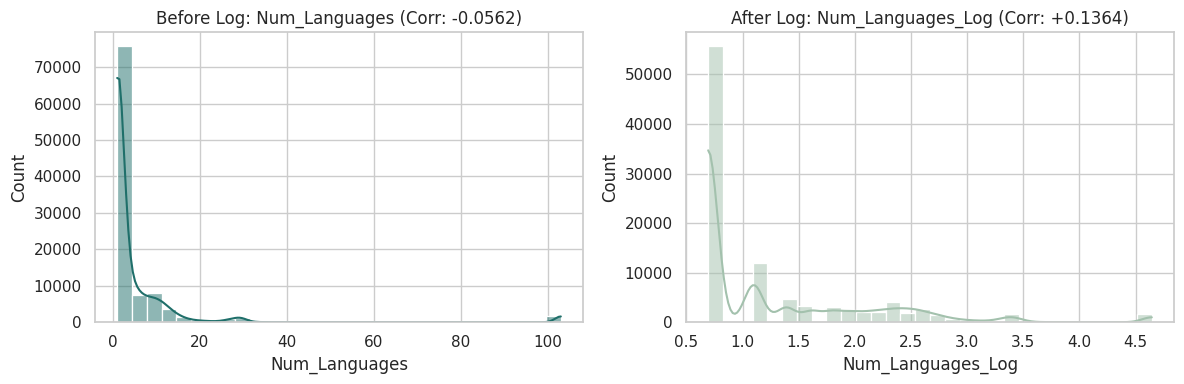

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.set_theme(style="whitegrid")

# 1. Before transformation: Original distribution of supported languages count
sns.histplot(df_corr_analysis['Num_Languages'], bins=30, ax=axes[0], color='#1f6f6a', kde=True)
axes[0].set_title('Before Log: Num_Languages (Corr: -0.0562)')

# 2. After transformation: Distribution after applying log transformation
sns.histplot(df_corr_analysis['Num_Languages_Log'], bins=30, ax=axes[1], color='#a3c1ad', kde=True)
axes[1].set_title('After Log: Num_Languages_Log (Corr: +0.1364)')

plt.tight_layout()
plt.show()